# Phase 7 — GJR-GARCH Volatility Scaling
Runs the GJR-GARCH module and displays results. All logic lives in `src/volatility/gjr_garch.py`, this notebook only calls it and shows the charts.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt

from src.data_collection import config
from src.data_collection.saver import save_processed
from src.volatility.garch import fit_garch_model, get_conditional_volatility as get_garch_vol
from src.volatility.gjr_garch import (
    fit_gjr_garch_model, get_conditional_volatility, get_leverage_effect_parameter,
    forecast_volatility, gjr_garch_scaled_returns, gjr_garch_scaled_historical_var,
)
from src.var.historical import calculate_historical_var
from src.visualization import gjr_garch_charts
from src.visualization import charts

## Load Phase 3 output (portfolio returns)

In [2]:
portfolio_returns = pd.read_csv(
    config.DATA_PROCESSED_DIR / 'portfolio_returns_phase3.csv',
    index_col=0, parse_dates=True
).iloc[:, 0]
portfolio_returns.tail()

date
2026-07-16   -0.015001
2026-07-17   -0.014545
2026-07-20    0.001204
2026-07-21    0.011876
2026-07-22    0.006389
Name: portfolio_return, dtype: float64

## Fit GJR-GARCH

In [3]:
gjr_fitted = fit_gjr_garch_model(portfolio_returns, p=1, o=1, q=1)
print(gjr_fitted.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:       portfolio_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -2434.65
Distribution:                  Normal   AIC:                           4879.31
Method:            Maximum Likelihood   BIC:                           4905.50
                                        No. Observations:                 1393
Date:                Tue, Sep 01 2026   Df Residuals:                     1392
Time:                        21:36:39   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1075  3.514e-02      3.059  2.224e-03 [3.860e-0

In [4]:
conditional_vol = get_conditional_volatility(gjr_fitted)
leverage = get_leverage_effect_parameter(gjr_fitted)
print(f'Leverage effect parameter (gamma): {leverage:.4f}')
print('Positive gamma -> negative returns increase future volatility more than positive returns of the same size.')

Leverage effect parameter (gamma): 0.1284
Positive gamma -> negative returns increase future volatility more than positive returns of the same size.


In [5]:
forecast = forecast_volatility(gjr_fitted, horizon=10)
forecast

1     0.012887
2     0.012942
3     0.012994
4     0.013044
5     0.013093
6     0.013140
7     0.013185
8     0.013228
9     0.013270
10    0.013310
Name: gjr_garch_forecast_volatility, dtype: float64

## GJR-GARCH-scaled VaR

In [6]:
scaled_returns = gjr_garch_scaled_returns(portfolio_returns, gjr_fitted)

hist_var_95 = calculate_historical_var(portfolio_returns, confidence_level=0.95)
gjr_var_95 = gjr_garch_scaled_historical_var(portfolio_returns, confidence_level=0.95)

print(f'Plain Historical VaR (95%):    {hist_var_95:.4f}')
print(f'GJR-GARCH-scaled VaR (95%):    {gjr_var_95:.4f}')

Plain Historical VaR (95%):    0.0238
GJR-GARCH-scaled VaR (95%):    0.0214


## Charts

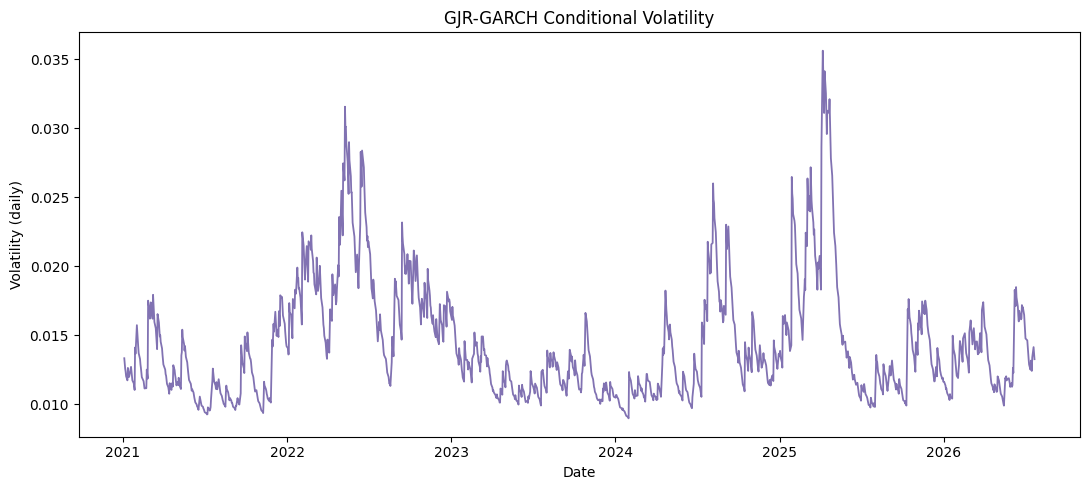

In [7]:
fig1 = gjr_garch_charts.plot_gjr_garch_volatility(conditional_vol)
plt.show()

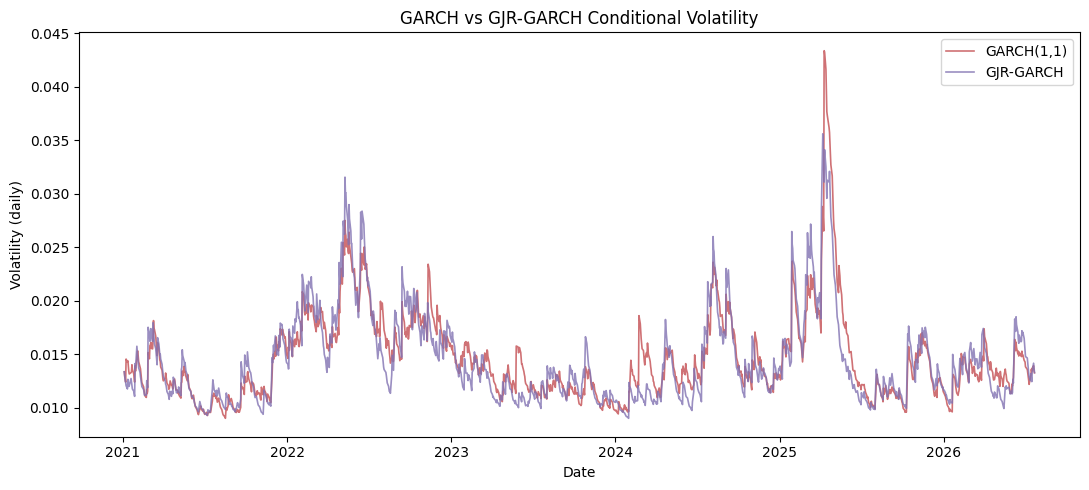

In [8]:
# Compare against plain GARCH (Phase 6) to see where they diverge
garch_fitted = fit_garch_model(portfolio_returns)
garch_vol = get_garch_vol(garch_fitted)
fig2 = gjr_garch_charts.plot_garch_vs_gjr_garch(garch_vol, conditional_vol)
plt.show()

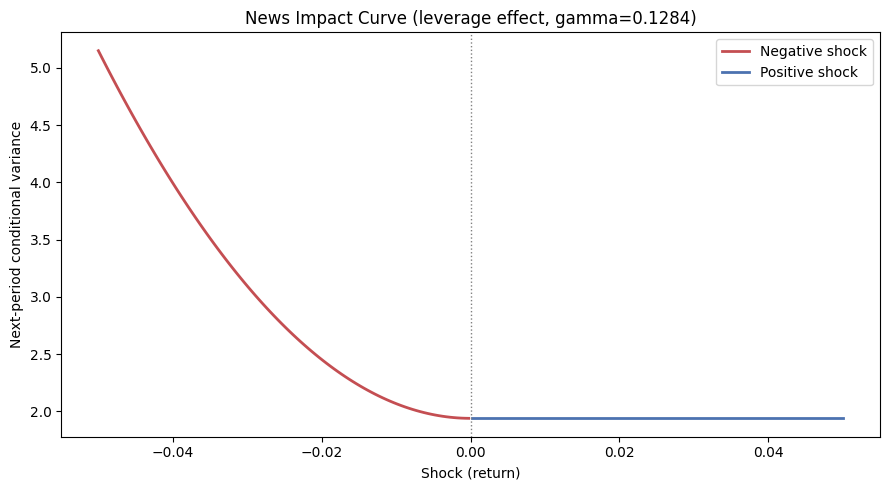

In [9]:
fig3 = gjr_garch_charts.plot_leverage_effect(gjr_fitted)
plt.show()

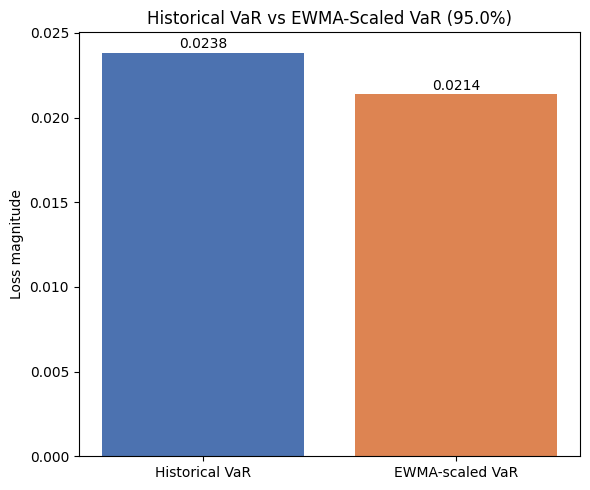

In [10]:
fig4 = charts.plot_var_comparison(hist_var_95, gjr_var_95, confidence_level=0.95)
plt.show()

## Save Phase 7 outputs

In [11]:
save_processed(conditional_vol.to_frame(), 'gjr_garch_conditional_volatility.csv', config.DATA_PROCESSED_DIR)
save_processed(forecast.to_frame(), 'gjr_garch_volatility_forecast.csv', config.DATA_PROCESSED_DIR)
save_processed(scaled_returns.to_frame(), 'gjr_garch_scaled_returns.csv', config.DATA_PROCESSED_DIR)
print('Phase 7 outputs saved.')

Phase 7 outputs saved.
